Adding a single sensor to a exponential component

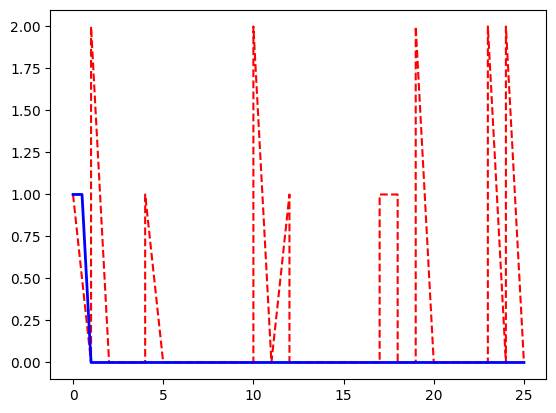

In [6]:
from sensor_objects.quality_based_sensor import QualityBasedSensor
from component_objects.component_exponential import ExponentialComponent

import matplotlib.pyplot as plt

# initialize comp and sensor 
comp = ExponentialComponent("test comp", MTTF= 10, MTTR=2)
sensor = QualityBasedSensor("s1", comp, quality= "Moderate")

sim_hours = 25
dt = 0.5
comp.simulate(sim_hours, dt)
sensor.read(sim_hours, dt)

plt.plot(sensor.sensed_history[:,0],  sensor.sensed_history[:,1], '--r')
plt.plot(comp.history[:,0], comp.history[:,1], 'b-', linewidth=2)

Comparing the accuracy of a Good vs Moderate vs Bad Single Sensor

In [24]:
from sensor_objects.quality_based_sensor import QualityBasedSensor
from component_objects.component_exponential import ExponentialComponent
from component_objects.component_weibull import WeibullComponent

import matplotlib.pyplot as plt
import numpy as np

# initialize a common comp
comp = WeibullComponent("test comp", MTTF= 10, MTTR=2)

# initialize 3 different types of sensors
s1 = QualityBasedSensor("s_good", comp, quality= "Good")
s2 = QualityBasedSensor("s_moderate", comp, quality= "Moderate")
s3 = QualityBasedSensor("s_bad", comp, quality= "Bad")

# simulate history and read with all sensors
sim_hours = 25
dt = 0.5
comp.simulate(sim_hours, dt)
s1.read(sim_hours, dt)
s2.read(sim_hours, dt)
s3.read(sim_hours, dt)

# check accuracy of each sensor
accuracy1 = np.sum(s1.sensed_history[:,1] == comp.history[:,1]) / len(comp.history)
accuracy2 = np.sum(s2.sensed_history[:,1] == comp.history[:,1]) / len(comp.history)
accuracy3 = np.sum(s3.sensed_history[:,1] == comp.history[:,1]) / len(comp.history)

# print the accuracy of each sensor type 
print(f"Good Sensor Accuracy = {accuracy1:2%}")
print(f"Moderate Sensor Accuracy = {accuracy2:2%}")
print(f"Bad Sensor Accuracy = {accuracy3:2%}")

Good Sensor Accuracy = 100.000000%
Moderate Sensor Accuracy = 76.470588%
Bad Sensor Accuracy = 47.058824%


Adding multiple Sensors to a Component usign sensed_component obj

In [ ]:
from sensor_objects.quality_based_sensor import QualityBasedSensor
from component_objects.component_exponential import ExponentialComponent
# from component_objects.component_weibull import WeibullComponent
from sensed_objects.sensed_component import SensedComponent

# initialize a component and multiple sensors
comp = ExponentialComponent("Comp w/ Multiple Sensors", MTTF=10, MTTR=2)
num_sensors = 3
sensors = [QualityBasedSensor(f"s{i+1}", comp, "Good") for i in range(num_sensors)]

# initialize the comp and sensors as a paired object
sc = SensedComponent(comp, sensors)

# attempt to simulate the sensed component and print the truth and sensed readings
sim_hours = 25
dt = 0.5
sc.simulate()

Combined Sensor Readings for Multiple Moderate Sensors